In [1]:
import pandas as pd
import numpy as np
import sklearn
import os
from datetime import datetime, timedelta
import time
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
import plotly.graph_objects as go


In [3]:
import seaborn as sns

In [4]:
from utils import *

In [5]:
#%%time
#tx_data = pd.read_csv('/home/research_group/preconfirmations/txs_20241201_20241205.csv')

In [6]:
%%time
tx_data = pd.read_csv('data/txs_sample.csv')

CPU times: user 301 ms, sys: 28.3 ms, total: 329 ms
Wall time: 330 ms


In [7]:
tx_data.head()

,block_number,tx_hash,position,gas_used,tx_topology,tx_fee,burnt_fee,priority_fee,priority_fee_per_gas,__row_index
0,21330579,0x1c3a9637cec8ba2bd2f2b97041b86fc0c8eab2c77e47...,0,146318,Other,0.009503,0.005019,0.004485,3.065000e-08,18980
1,21330579,0x70a47debfa8467a08119e952ae39df851a0ff3ad6392...,1,135890,Other,0.008826,0.004661,0.004165,3.065000e-08,18981
2,21330579,0xdca625b4066248651b50bdc404a51f7b1b53e2f71fcd...,2,21000,EthTransfer,0.102970,0.000720,0.102250,4.869034e-06,18982
3,21330579,0x8cd8c40b96d344593f46ca6a46c427d73eef3d62a542...,3,21000,EthTransfer,0.044130,0.000720,0.043410,2.067129e-06,18983
4,21330579,0xfa71429c40d68ec0880722508853ae7aa8237c5d0dbd...,4,137064,Other,0.022657,0.004701,0.017955,1.310000e-07,18984


In [17]:
aggregated = tx_data.groupby('position').agg(
    mean_priority_fee=('priority_fee_per_gas', 'mean'),
    min_priority_fee=('priority_fee_per_gas', 'min'),
    # max_priority_fee=('priority_fee_per_gas', 'max'),
    median_priority_fee=('priority_fee_per_gas', 'median'),
    quantile_25_priority_fee=('priority_fee_per_gas', lambda x: x.quantile(0.25)),
    quantile_75_priority_fee=('priority_fee_per_gas', lambda x: x.quantile(0.75)),
    quantile_95_priority_fee=('priority_fee_per_gas', lambda x: x.quantile(0.95))
)


In [24]:
aggregated2 = tx_data.groupby('block_number').agg(
    mean_priority_fee=('priority_fee_per_gas', 'mean'),
    min_priority_fee=('priority_fee_per_gas', 'min'),
    # max_priority_fee=('priority_fee_per_gas', 'max'),
    median_priority_fee=('priority_fee_per_gas', 'median'),
    quantile_25_priority_fee=('priority_fee_per_gas', lambda x: x.quantile(0.25)),
    quantile_75_priority_fee=('priority_fee_per_gas', lambda x: x.quantile(0.75)),
    # quantile_95_priority_fee=('priority_fee_per_gas', lambda x: x.quantile(0.95))
)


<Axes: xlabel='block_number'>

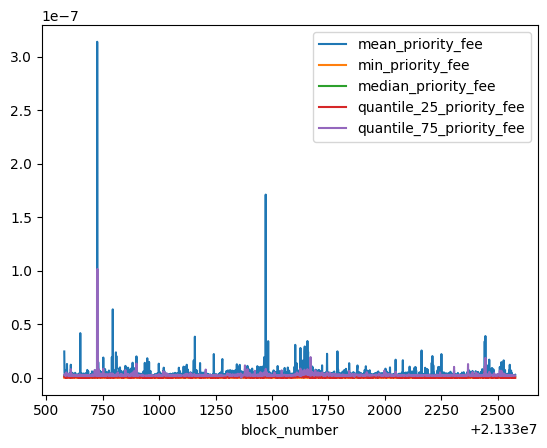

In [25]:
aggregated2.plot()

In [8]:
tx_data.dtypes

block_number              int64
tx_hash                  object
position                  int64
gas_used                  int64
tx_topology              object
tx_fee                  float64
burnt_fee               float64
priority_fee            float64
priority_fee_per_gas    float64
__row_index               int64
dtype: object

In [9]:
#tx_data.loc[tx_data.block_number >= 21330579].to_csv('/home/research_group/preconfirmations/txs_sample.csv', index=False)

In [10]:
#eligible_txs.to_csv('/home/research_group/preconfirmations/eligible_txs_sample.csv', index=False)

In [11]:
block_features = build_block_features(tx_data)

In [12]:
block_features

,block_number,block_gas_used,tx_count,block_gas_used_log_1,tx_count_log_1
0,21330579,28684964,383,NaN,NaN
1,21330580,11648827,153,28684964.0,383.0
2,21330581,13590577,182,11648827.0,153.0
3,21330582,11834295,166,13590577.0,182.0
4,21330583,10679739,174,11834295.0,166.0
...,...,...,...,...,...
1995,21332574,16831450,207,11760090.0,174.0
1996,21332575,10968930,141,16831450.0,207.0
1997,21332576,24192405,233,10968930.0,141.0
1998,21332577,9500884,118,24192405.0,233.0


In [13]:
# Categorise blocks as a function of the gas used
threshold = 29*1e6
block_features['block_category'] = (block_features.block_gas_used_log_1 > threshold)*1.

Model:
- Filter txs on t2 (position 10->150)

Possibilities:
- Train 1 model per (topology x network congestion state)
- Train 1 model and consider tx_gas_used, prev_block_gas_used

Model evaluation:
- We can evaluate the number of preconfirmed txs by looking at $PF > estimated PF$

Problems: 
- We do not take into account "bad pricing" i.e. cases when the estimated PF is bad. 
- PF per gas may not be the best metric as we care about pricing well txs that are profitable (high gas usage) as PF = PF per gas x gas used

In [13]:
eligible_txs = tx_data.loc[(tx_data.position > 10) & (tx_data.position < 150)]

In [14]:
print(len(eligible_txs) / len(tx_data))

0.6848369355835439


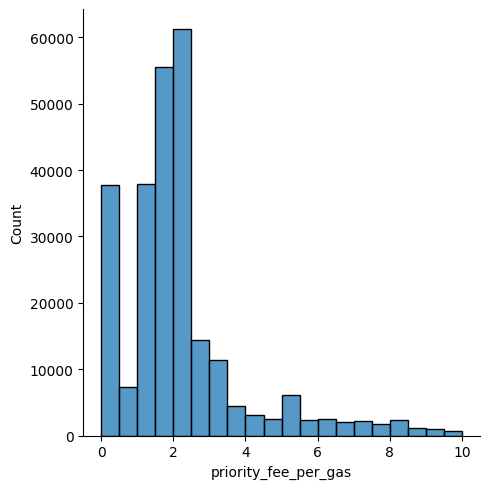

In [15]:
sns.displot(eligible_txs.priority_fee_per_gas.loc[eligible_txs.priority_fee_per_gas < 10e-9]*1e9, bins=20)

In [16]:
%%time
lags = np.arange(1, 20, 1)
agg_df = build_agg_features(eligible_txs, lags)

CPU times: user 73.2 ms, sys: 14.7 ms, total: 87.9 ms
Wall time: 96.7 ms


In [17]:
agg_df

,tx_topology,block_number,q10_priority_fee_per_gas,q20_priority_fee_per_gas,q30_priority_fee_per_gas,q40_priority_fee_per_gas,q50_priority_fee_per_gas,q60_priority_fee_per_gas,q70_priority_fee_per_gas,q80_priority_fee_per_gas,...,q40_priority_fee_per_gas_lag_19,q50_priority_fee_per_gas_lag_19,q60_priority_fee_per_gas_lag_19,q70_priority_fee_per_gas_lag_19,q80_priority_fee_per_gas_lag_19,q90_priority_fee_per_gas_lag_19,mean_priority_fee_per_gas_lag_19,min_priority_fee_per_gas_lag_19,max_priority_fee_per_gas_lag_19,skew_priority_fee_per_gas_lag_19
0,Approve,21330579,1.922061e-09,1.937307e-09,1.940000e-09,1.976000e-09,2.000000e-09,2.000000e-09,2.282967e-09,2.961705e-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Approve,21330580,9.799000e-10,1.881800e-09,2.410464e-09,2.939128e-09,3.969564e-09,5.000000e-09,5.000000e-09,5.000000e-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Approve,21330581,1.000000e-09,1.529080e-09,1.881800e-09,1.947430e-09,2.209950e-09,2.793292e-09,2.975651e-09,3.000000e-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Approve,21330582,9.878096e-10,1.875619e-09,1.907810e-09,1.940000e-09,2.470000e-09,3.000000e-09,3.079560e-09,3.159120e-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Approve,21330583,1.433432e-09,1.890747e-09,1.917588e-09,1.931921e-09,1.940000e-09,1.940000e-09,1.952000e-09,1.988000e-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10484,Withdraw,21332567,1.665944e-09,1.665944e-09,1.665944e-09,1.665944e-09,1.665944e-09,1.665944e-09,1.665944e-09,1.665944e-09,...,2.658155e-09,2.661955e-09,2.665754e-09,2.669553e-09,2.673352e-09,2.677152e-09,2.661955e-09,2.642958e-09,2.680951e-09,NaN
10485,Withdraw,21332568,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,...,1.296541e-09,1.370676e-09,1.444811e-09,1.518946e-09,1.593081e-09,1.667216e-09,1.370676e-09,1.000000e-09,1.741351e-09,NaN
10486,Withdraw,21332570,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,...,2.557038e-09,2.557038e-09,2.557038e-09,2.557038e-09,2.557038e-09,2.557038e-09,2.557038e-09,2.557038e-09,2.557038e-09,NaN
10487,Withdraw,21332571,2.260521e-09,2.260521e-09,2.260521e-09,2.260521e-09,2.260521e-09,2.260521e-09,2.260521e-09,2.260521e-09,...,1.596964e-09,1.596964e-09,1.596964e-09,1.596964e-09,1.596964e-09,1.596964e-09,1.596964e-09,1.596964e-09,1.596964e-09,NaN


In [18]:
final_df = eligible_txs.merge(agg_df, on=['block_number', 'tx_topology']).merge(block_features, on='block_number')

In [19]:
final_df.columns

Index(['block_number', 'tx_hash', 'position', 'gas_used', 'tx_topology',
       'tx_fee', 'burnt_fee', 'priority_fee', 'priority_fee_per_gas',
       '__row_index',
       ...
       'q80_priority_fee_per_gas_lag_19', 'q90_priority_fee_per_gas_lag_19',
       'mean_priority_fee_per_gas_lag_19', 'min_priority_fee_per_gas_lag_19',
       'max_priority_fee_per_gas_lag_19', 'skew_priority_fee_per_gas_lag_19',
       'block_gas_used', 'tx_count', 'block_gas_used_log_1', 'tx_count_log_1'],
      dtype='object', length=274)

In [31]:
%%time
final_df = pd.read_csv('/home/research_group/preconfirmations/final_df.csv')

CPU times: user 8.55 s, sys: 240 ms, total: 8.79 s
Wall time: 8.78 s


In [36]:
block_features.to_csv('/home/research_group/preconfirmations/block_features.csv', index=False)

In [7]:
block_features = pd.read_csv('data/block_features.csv')

In [8]:
%%time
lags = np.arange(1, 33, 1)
eligible_txs = pd.read_csv('data/eligible_txs_sample.csv')
agg_df = build_agg_features(eligible_txs, lags)
final_df = eligible_txs.merge(agg_df, on=['block_number', 'tx_topology']).merge(block_features, on='block_number')

CPU times: user 510 ms, sys: 357 ms, total: 867 ms
Wall time: 923 ms


In [9]:
block_features

,block_number,block_gas_used,tx_count,block_gas_used_log_1,tx_count_log_1,block_category
0,21330579,28684964,383,NaN,NaN,0.0
1,21330580,11648827,153,28684964.0,383.0,0.0
2,21330581,13590577,182,11648827.0,153.0,0.0
3,21330582,11834295,166,13590577.0,182.0,0.0
4,21330583,10679739,174,11834295.0,166.0,0.0
...,...,...,...,...,...,...
1995,21332574,16831450,207,11760090.0,174.0,0.0
1996,21332575,10968930,141,16831450.0,207.0,0.0
1997,21332576,24192405,233,10968930.0,141.0,0.0
1998,21332577,9500884,118,24192405.0,233.0,0.0


In [10]:
est = rolling_mean_block_pf_estimator(final_df, 'q50', lags)

In [11]:
metrics, groups = compute_metrics(est)

In [12]:
metrics

{'mae': 1.5849739961395792,
 'avg_preconfirmed_errors': 1.1251289317241182,
 'preconfirmations_eligible': 0.4784676523696915,
 'preconf_value': 39.566061191522316}

In [21]:
q_pl = generate_placeholder()
lr_pl = generate_placeholder()
ml_pl = generate_placeholder()

In [20]:
import plotly.graph_objects as go
import pandas as pd

def plot_grouped_bar(value_to_plot, q_pl, lr_pl, ml_pl):
    """
    Plots a grouped bar chart for the given value from three dictionaries (q_pl, lr_pl, ml_pl).
    
    Args:
        value_to_plot (str): The key for the value to plot (e.g., 'avg_preconfirmed_errors').
        q_pl (dict): First dictionary with tx_topologies as keys.
        lr_pl (dict): Second dictionary with tx_topologies as keys.
        ml_pl (dict): Third dictionary with tx_topologies as keys.
        
    Returns:
        fig (plotly.graph_objects.Figure): The grouped bar chart figure.
    """
    # Extract transaction topologies (they should be consistent across the 3 dictionaries)
    tx_topologies = list(q_pl.keys())
    
    # Extract the values for the specified key from each dictionary
    q_values = [q_pl[tx][value_to_plot] for tx in tx_topologies]
    lr_values = [lr_pl[tx][value_to_plot] for tx in tx_topologies]
    ml_values = [ml_pl[tx][value_to_plot] for tx in tx_topologies]

    # Create the bar traces for each of the dictionaries
    trace_q = go.Bar(
        x=tx_topologies, 
        y=q_values, 
        name='Q PL',
        marker_color='rgb(55, 83, 109)'
    )

    trace_lr = go.Bar(
        x=tx_topologies, 
        y=lr_values, 
        name='LR PL',
        marker_color='rgb(26, 118, 255)'
    )

    trace_ml = go.Bar(
        x=tx_topologies, 
        y=ml_values, 
        name='ML PL',
        marker_color='rgb(50, 205, 50)'
    )

    # Combine traces into one figure
    fig = go.Figure(data=[trace_q, trace_lr, trace_ml])
    
    # Update layout to make it more readable
    fig.update_layout(
        title=f'Grouped Bar Plot for {value_to_plot}',
        xaxis_title='Transaction Topology',
        yaxis_title=value_to_plot,
        barmode='group',  # This creates the "grouped" effect
        xaxis_tickangle=-45
    )

    return fig


In [22]:
fig = plot_grouped_bar('avg_preconfirmed_errors', q_pl, lr_pl, ml_pl)


In [23]:
fig.show()

In [70]:
# LR

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

def train_linear_regression(df, features, features_lag, lags, training_threshold, target='priority_fee_per_gas'):
    """
    Trains a Linear Regression model using lagged features.
    
    Args:
        df (DataFrame): The DataFrame containing all data with features and lags.
        features (list): List of base features to be used as predictors.
        lags (list): List of lags to be applied to each feature.
        training_threshold (int): The block number threshold to split the train and test data.
        target (str): The name of the target variable column (default is 'priority_fee_per_gas').
        
    Returns:
        dict: A dictionary containing the trained model, predictions, and metrics.
    """
    # 1️⃣ Generate the feature columns from features + lags
    feature_columns = [f'{feature}_lag_{lag}' for feature in features_lag for lag in lags]
    feature_columns += features
    
    # Ensure that the required feature columns exist in the DataFrame
    missing_features = [col for col in feature_columns if col not in df.columns]
    if missing_features:
        raise ValueError(f"The following required features are missing from the DataFrame: {missing_features}")
    
    # 2️⃣ Split the data into training and testing sets
    train_data = df[df['block_number'] <= training_threshold]
    test_data = df[df['block_number'] > training_threshold]
    
    # Remove any rows with NaN values (caused by shift() operations)
    train_data = train_data.dropna(subset=feature_columns + [target])
    test_data = test_data.dropna(subset=feature_columns + [target])
    
    # 3️⃣ Extract X (features) and y (target) for training and testing
    X_train = train_data[feature_columns]
    y_train = train_data[target]
    X_test = test_data[feature_columns]
    y_test = test_data[target]
    
    # 4️⃣ Train the Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # 5️⃣ Make predictions on the test data
    y_pred = model.predict(X_test)
    
    r2 = model.score(X_test, y_test)
    
    # 7️⃣ Return the model, predictions, and metrics
    results = pd.DataFrame()
    results['y_pred'] = y_pred
    results['y_true'] = y_test.reset_index(drop=True)
    results['block_number'] = test_data['block_number'].reset_index(drop=True)
    results['tx_topology'] = test_data['tx_topology'].reset_index(drop=True)
    results['gas_used'] = test_data['gas_used'].reset_index(drop=True)
    return results, r2



In [71]:
# Features and lags to include
features = ['gas_used']
features_lag = ['q50_priority_fee_per_gas', 'mean_priority_fee_per_gas', 'q20_priority_fee_per_gas']
lags = [1, 2, 3, 4, 5]
training_threshold = 21331500

# Call the function to train the model
results, r2 = train_linear_regression(final_df, features, features_lag, lags, training_threshold)



In [73]:
compute_metrics(results)

({'mae': np.float64(1.8251427978003234),
  'mse': np.float64(4.526949556396691e-17),
  'avg_preconfirmed_errors': np.float64(0.9241506144802475),
  'preconfirmations_eligible': np.float64(0.2402490848655699),
  'nb_preconf': 34260,
  'ratio_eligible_errors': np.float64(0.25996745671233323),
  'n_tx': 142602,
  'preconf_value': np.float64(16.69764158387644)},
 {'Approve': {'avg_preconfirmed_errors': np.float64(0.7708894122752228),
   'preconfirmations_eligible': np.float64(0.32989228007181326),
   'preconf_value': np.float64(0.6669620619523906)},
  'EthTransfer': {'avg_preconfirmed_errors': np.float64(0.8552416881387458),
   'preconfirmations_eligible': np.float64(0.21044375159323098),
   'preconf_value': np.float64(1.507579181647793)},
  'Other': {'avg_preconfirmed_errors': np.float64(1.2170995488174243),
   'preconfirmations_eligible': np.float64(0.2969592709689418),
   'preconf_value': np.float64(12.145056070735908)},
  'SetApprovalForAll': {'avg_preconfirmed_errors': np.float64(0.07

In [74]:
r2

0.004176915562907224

In [57]:
[c for c in final_df.columns if 'q25_priority_fee_per_gas' in c]

[]

In [52]:
final_df['priority_fee_per_gas_lag_1']

KeyError: 'priority_fee_per_gas_lag_1'

In [12]:
valid_statistics = ['mean', 'median', 'q25', 'q75', 'q60']
results = []
groups = {}
for st in valid_statistics:
    print(st)
    lags = np.arange(1, 2)
    agg = compute_lags_stat(eligible_txs, 'priority_fee_per_gas', st, lags)
    final_df = eligible_txs.merge(agg, on=['block_number', 'tx_topology'])
    est = last_block_pf_estimator(final_df, st)
    res, group = compute_metrics(est)
    results.append(res)
    groups[st] = group
results = pd.DataFrame(results, index = valid_statistics)

mean
median
q25
q75
q60


In [9]:
results

,mae,mse,avg_preconfirmed_errors,preconfirmations_eligible,nb_preconf,ratio_eligible_errors,n_tx,preconf_value
mean,2.043286,5.570459e-17,1.018513,0.361437,95679,0.354868,264718,33.862997
median,1.700957,5.307176e-17,1.188590,0.461332,122123,0.388134,264718,38.841973
q25,1.897517,5.448550e-17,1.645741,0.681325,180359,0.413993,264718,46.121751
q75,2.061498,5.634776e-17,0.914899,0.255751,67702,0.279541,264718,29.371009
q60,1.746744,5.330528e-17,1.072643,0.375131,99304,0.349726,264718,35.343086


In [13]:
groups

{'mean': {'Approve': {'mae': np.float64(1.8408003382228497),
   'avg_preconfirmed_errors': np.float64(0.9699916119819091),
   'preconfirmations_eligible': np.float64(0.462667709524096),
   'ratio_eligible_errors': np.float64(4.7698114479439955e+17),
   'preconf_value': np.float64(1.4141151462955366)},
  'EthTransfer': {'mae': np.float64(2.0311811253808423),
   'avg_preconfirmed_errors': np.float64(0.9565960635286556),
   'preconfirmations_eligible': np.float64(0.33386402935346465),
   'ratio_eligible_errors': np.float64(3.490125478061446e+17),
   'preconf_value': np.float64(3.2438644961078786)},
  'Other': {'mae': np.float64(2.475745581178686),
   'avg_preconfirmed_errors': np.float64(1.3168921714174264),
   'preconfirmations_eligible': np.float64(0.38942690975625693),
   'ratio_eligible_errors': np.float64(2.9571662601433824e+17),
   'preconf_value': np.float64(23.62393388262179)},
  'SetApprovalForAll': {'mae': np.float64(0.5177923510866927),
   'avg_preconfirmed_errors': np.float64(

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Example input dictionary

# Extract data for plotting
tx_topologies = list(next(iter(groups.values())).keys())
heuristics = list(groups.keys())
values_to_plot = 'preconf_value'

# Prepare data for plotting
bar_width = 0.2  # Width of each bar
gap_between_topologies = 0.5  # Extra gap between groups of transaction topologies

n_tx_topologies = len(tx_topologies)
x = np.arange(n_tx_topologies) * (len(heuristics) * bar_width + gap_between_topologies)
offsets = np.linspace(-bar_width * (len(heuristics) - 1) / 2, bar_width * (len(heuristics) - 1) / 2, len(heuristics))

# Create plot
plt.figure(figsize=(10, 6))

for i, heuristic in enumerate(heuristics):
    heights = [groups[heuristic][tx_topology][values_to_plot] for tx_topology in tx_topologies]
    plt.bar(x + offsets[i], heights, width=bar_width, label=heuristic)

# Customizations
plt.xlabel('Transaction Topology')
plt.ylabel(values_to_plot.replace('_', ' ').title())
plt.title(f'Comparison of {values_to_plot.replace("_", " ").title()} by Heuristic and Transaction Topology')
plt.xticks(ticks=x, labels=tx_topologies)
plt.legend(title='Heuristic')
plt.tight_layout()

# Show plot
plt.show()


IndexError: invalid index to scalar variable.

<Figure size 1000x600 with 0 Axes>

In [8]:
np.arange(0.1, 1, 0.1)

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [38]:
valid_statistics = ['mean', 'median', 'q25', 'q75', 'q60']
results_rolling = []
lags = np.arange(1, 10)

for st in valid_statistics:
    print(st)
    agg = compute_lags_stat(eligible_txs, 'priority_fee_per_gas', st, lags)
    final_df = eligible_txs.merge(agg, on=['block_number', 'tx_topology'])
    est = rolling_mean_block_pf_estimator(final_df, st, lags)
    res = compute_metrics(est)
    results_rolling.append(res)
results_rolling = pd.DataFrame(results_rolling, index = valid_statistics)

mean
median
q25
q75
q60


In [39]:
results_rolling

,mae,mse,avg_preconfirmed_errors,preconfirmations_eligible,nb_preconf,ratio_eligible_errors,n_tx
mean,1.670991,8.820086e-16,0.844214,0.339544,1268202,0.402201,3735014
median,1.450909,8.867812e-16,1.017833,0.502924,1878428,0.494113,3735014
q25,1.636499,8.888943e-16,1.453266,0.737782,2755626,0.507672,3735014
q75,1.705110,8.842386e-16,0.762585,0.255182,953110,0.334628,3735014
q60,1.489708,8.859162e-16,0.912242,0.393561,1469955,0.431421,3735014
